# 03 — Auditing network changes after deleting HLJ1

**Question.** Which changes in network scores are reproducible after removing HLJ1, and how much do the results depend on the metric and network construction?

We compare:

| Choice | Values |
|---|---|
| Metric | Weighted PageRank; sampled-source betweenness |
| Betweenness path definition | Minimum hops; minimum confidence cost |
| Functional score filter | ≥700; ≥750; >750 |
| Vertex set | All proteins; largest connected component selected **before** deletion |
| Difference | Always report both after − before and before − after |

The frozen ≥700 full network remains the **primary analysis**. The other settings are sensitivity or replication scenarios. The >750 setting reflects the `<= 750` edge-removal condition visible in Alex's earlier notebook; matching its node count does not establish that every preprocessing step is identical.

Deleting a node from a STRING association network is a structural simulation. A higher score after deletion does **not** predict higher protein expression or activity.

In [1]:
from pathlib import Path
from itertools import combinations
import hashlib
import json
import math
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PROCESSED = ROOT / "data" / "processed" / "string_v12_0"
META = ROOT / "data" / "metadata"
NB02 = ROOT / "outputs" / "notebook_02"
OUTPUT = ROOT / "outputs" / "notebook_03"
FIGURES = ROOT / "figures"

OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

design_path = META / "string_analysis_design_v12_0.json"
seed_path = META / "erad_seeds.csv"
functional_path = (
    PROCESSED / "functional_edges_score_ge_400.csv.gz"
)
physical_path = (
    PROCESSED / "physical_edges_score_ge_400.csv.gz"
)
id_map_path = PROCESSED / "string_id_to_orf.csv"

design = json.loads(design_path.read_text(encoding="utf-8"))
nb02_record = json.loads(
    (NB02 / "run_record.json").read_text(encoding="utf-8")
)

assert sha256(design_path) == nb02_record["frozen_design_sha256"]
assert sha256(seed_path) == nb02_record["seed_table_sha256"]
assert sha256(functional_path) == (
    nb02_record["functional_processed_sha256"]
)
assert sha256(physical_path) == (
    nb02_record["physical_processed_sha256"]
)

id_map = pd.read_csv(id_map_path, dtype=str).fillna("")
assert id_map["string_protein_id"].is_unique

functional_edges = pd.read_csv(
    functional_path,
    usecols=["u", "v", "combined_score"],
)[["u", "v", "combined_score"]]

physical_edges = pd.read_csv(
    physical_path,
    usecols=["u", "v", "combined_score"],
)[["u", "v", "combined_score"]]

h = design["hlj1_string_id"]
R = set(
    id_map.loc[
        id_map["orf"].isin(design["core_seed_orfs"]),
        "string_protein_id",
    ]
)
S = R - {h}

assert h in R and len(R) == 6 and len(S) == 5

print("Frozen inputs verified.")
print("HLJ1:", h)
print("Surviving seeds:", sorted(S))

Frozen inputs verified.
HLJ1: 4932.YMR161W
Surviving seeds: ['4932.YBR201W', '4932.YLR207W', '4932.YMR022W', '4932.YMR264W', '4932.YOL013C']


## 1. Define the graph scenarios precisely

For score $c_{ij}$, an edge is included according to the scenario's `≥` or `>` rule. Its confidence is

$$w_{ij}=c_{ij}/1000.$$

For confidence-based shortest paths, use the positive path length

$$\ell_{ij}=-\log(w_{ij}).$$

A STRING score is a confidence value, **not** a path length. Passing the raw score to a shortest-path algorithm would make high-confidence edges appear longer.

For a largest-component scenario, select the component on the intact graph $G$, then form $G-h$. **Do not select a new largest component after deletion:** doing so would remove additional proteins and confound the comparison.

In [3]:
ALL_IDS = set(id_map["string_protein_id"])

def make_graph(edges, cutoff, strict=False, scope="full"):
    if strict:
        selected = edges.loc[
            edges["combined_score"] > cutoff,
            ["u", "v", "combined_score"],
        ]
    else:
        selected = edges.loc[
            edges["combined_score"] >= cutoff,
            ["u", "v", "combined_score"],
        ]

    assert set(selected["u"]) | set(selected["v"]) <= ALL_IDS
    assert not (selected["u"] == selected["v"]).any()
    assert not selected[["u", "v"]].duplicated().any()

    graph = nx.Graph()
    graph.add_nodes_from(id_map["string_protein_id"])

    graph.add_edges_from(
        (
            u,
            v,
            {
                "confidence": score / 1000,
                "length": -math.log(score / 1000),
            },
        )
        for u, v, score in selected.itertuples(
            index=False, name=None
        )
    )

    if scope == "lcc":
        largest = max(nx.connected_components(graph), key=len)
        graph = graph.subgraph(largest).copy()
    elif scope != "full":
        raise ValueError(f"Unknown scope: {scope}")

    assert h in graph
    assert all(
        data["length"] > 0
        for _, _, data in graph.edges(data=True)
    )
    return graph

SCENARIOS = [
    {
        "name": "ge700_full_PRIMARY",
        "cutoff": 700,
        "strict": False,
        "scope": "full",
    },
    {
        "name": "ge700_lcc",
        "cutoff": 700,
        "strict": False,
        "scope": "lcc",
    },
    {
        "name": "ge750_full",
        "cutoff": 750,
        "strict": False,
        "scope": "full",
    },
    {
        "name": "ge750_lcc",
        "cutoff": 750,
        "strict": False,
        "scope": "lcc",
    },
    {
        "name": "gt750_lcc_ALEX_OLD_FILTER",
        "cutoff": 750,
        "strict": True,
        "scope": "lcc",
    },
]

construction_rows = []
for setting in SCENARIOS:
    graph = make_graph(
        functional_edges,
        cutoff=setting["cutoff"],
        strict=setting["strict"],
        scope=setting["scope"],
    )
    construction_rows.append({
        "scenario": setting["name"],
        "nodes_before": graph.number_of_nodes(),
        "edges_before": graph.number_of_edges(),
        "HLJ1_degree": graph.degree(h),
        "surviving_seed_count": len(S & set(graph)),
    })

construction = pd.DataFrame(construction_rows)
display(construction)

primary = construction.loc[
    construction["scenario"] == "ge700_full_PRIMARY"
].iloc[0]

assert int(primary["nodes_before"]) == 6600
assert int(primary["edges_before"]) == 104188
assert int(primary["HLJ1_degree"]) == 25

,scenario,nodes_before,edges_before,HLJ1_degree,surviving_seed_count
0,ge700_full_PRIMARY,6600,104188,25,5
1,ge700_lcc,5716,104138,25,5
2,ge750_full,6600,91503,19,5
3,ge750_lcc,5521,91384,19,5
4,gt750_lcc_ALEX_OLD_FILTER,5519,91154,19,5


## 2. Diagnose the original pathway-efficiency endpoint

The five surviving ERAD seeds are fixed as $S=R\setminus\{h\}$. Their hop-based pathway efficiency is

$$E_S^{\text{hop}}(G)=\frac{1}{\binom{|S|}{2}}\sum_{\{a,b\}\subset S}\frac{1}{d_G^{\text{hop}}(a,b)}.$$

If all pairs in $S$ already have direct edges, then every distance equals one. Deleting any protein outside $S$ leaves those direct edges intact, so this endpoint **cannot detect a change**. We must report this result instead of running an uninformative matched-deletion test on it.

In [4]:
G_primary = make_graph(
    functional_edges, cutoff=700, scope="full"
)
G_primary_after = G_primary.copy()
G_primary_after.remove_node(h)

seed_pairs = list(combinations(sorted(S), 2))

def seed_efficiency(graph, pairs, distance_type):
    values = []

    for a, b in pairs:
        if distance_type == "hop":
            distance = nx.shortest_path_length(graph, a, b)
            values.append(1 / distance)
        elif distance_type == "confidence":
            distance = nx.shortest_path_length(
                graph, a, b, weight="length"
            )
            values.append(math.exp(-distance))
        else:
            raise ValueError(distance_type)

    return float(np.mean(values))

direct_seed_pairs = sum(
    G_primary.has_edge(a, b) for a, b in seed_pairs
)

efficiency_diagnostic = pd.DataFrame([
    {
        "distance_type": kind,
        "seed_pairs": len(seed_pairs),
        "direct_seed_pairs": direct_seed_pairs,
        "before": seed_efficiency(
            G_primary, seed_pairs, kind
        ),
        "after_HLJ1_deletion": seed_efficiency(
            G_primary_after, seed_pairs, kind
        ),
    }
    for kind in ["hop", "confidence"]
])

efficiency_diagnostic["loss"] = (
    efficiency_diagnostic["before"]
    - efficiency_diagnostic["after_HLJ1_deletion"]
)

display(efficiency_diagnostic)

assert direct_seed_pairs == 10
assert np.isclose(
    efficiency_diagnostic.loc[
        efficiency_diagnostic["distance_type"] == "hop",
        "loss",
    ].iloc[0],
    0.0,
)

,distance_type,seed_pairs,direct_seed_pairs,before,after_HLJ1_deletion,loss
0,hop,10,10,1.000000,1.000000,0.0
1,confidence,10,10,0.998301,0.998301,0.0


## 3. Use comparable deletion scores

### PageRank

Let $\mathbf p_0$ be PageRank on $G$ and $\mathbf p_1$ PageRank on $G-h$. Because the second vector no longer has an HLJ1 entry, we record two comparisons for each surviving protein $v$:

$$\Delta p_v^{\mathrm{raw}}=p_{1,v}-p_{0,v},$$

$$\widetilde p_{0,v}=\frac{p_{0,v}}{1-p_{0,h}},\qquad\Delta p_v^{\mathrm{survivors}}=p_{1,v}-\widetilde p_{0,v}.$$

The second version compares distributions whose mass across surviving proteins is one. Neither version predicts expression changes.

### Betweenness

Use **the same surviving source and target proteins before and after deletion**. Let $Q$ be a fixed sample of source proteins and $U=V(G)\setminus\{h\}$ the scenario's surviving target set. For a surviving protein $v$,

$$B_{Q,U}(v;G)=\sum_{q\in Q}\sum_{t\in U}\frac{\sigma_{qt}^{G}(v)}{\sigma_{qt}^{G}},$$

where disconnected pairs contribute zero. Calculate this on both $G$ and $G-h$, using either hop-shortest paths or confidence-cost-shortest paths.

We use a fixed sample of 32 sources so the five-scenario comparison runs promptly. **This is sampled-source betweenness, not exact all-pairs betweenness.** Increase the sample and check stability before making a final candidate claim.

For every metric, the principal sign convention is

$$\Delta=\text{after}-\text{before}.$$

We also export its negative, `before_minus_after`, so Alex's convention can be checked without guessing. Relative changes are displayed only when the baseline is large enough; they are not the primary ranking.

[NetworkX PageRank documentation](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html) · [NetworkX subset-betweenness documentation](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality_subset.html)

In [5]:
# Draw sources from proteins present in every scenario.
# This prevents the source sample itself from changing.
common_nodes = None

for setting in SCENARIOS:
    graph = make_graph(
        functional_edges,
        cutoff=setting["cutoff"],
        strict=setting["strict"],
        scope=setting["scope"],
    )
    current = set(graph) - {h}
    common_nodes = (
        current if common_nodes is None
        else common_nodes & current
    )
    del graph

SOURCE_SAMPLE_SIZE = 32
SOURCE_RANDOM_SEED = 3888

assert len(common_nodes) >= SOURCE_SAMPLE_SIZE

sampled_sources = random.Random(
    SOURCE_RANDOM_SEED
).sample(
    sorted(common_nodes),
    SOURCE_SAMPLE_SIZE,
)

print(
    "Common surviving proteins:",
    len(common_nodes),
    "| fixed sampled sources:",
    len(sampled_sources),
)

Common surviving proteins: 5518 | fixed sampled sources: 32


In [6]:
def add_change_columns(
    frame, prefix, ids, before, after, relative_floor
):
    before_values = ids.map(before).astype(float)
    after_values = ids.map(after).astype(float)
    delta = after_values - before_values

    frame[f"{prefix}_before"] = before_values
    frame[f"{prefix}_after"] = after_values
    frame[f"{prefix}_after_minus_before"] = delta
    frame[f"{prefix}_before_minus_after"] = -delta

    # A tiny or zero baseline makes percentages misleading.
    safe_baseline = before_values.where(
        before_values >= relative_floor
    )
    frame[f"{prefix}_relative_change"] = (
        delta / safe_baseline
    )

def analyse_scenario(setting):
    graph = make_graph(
        functional_edges,
        cutoff=setting["cutoff"],
        strict=setting["strict"],
        scope=setting["scope"],
    )

    survivors = sorted(set(graph) - {h})
    assert set(sampled_sources) <= set(survivors)
    assert S <= set(survivors)

    deleted = graph.copy()
    deleted.remove_node(h)

    assert set(deleted) == set(survivors)
    assert deleted.number_of_edges() == (
        graph.number_of_edges() - graph.degree(h)
    )

    # Weighted PageRank. The weights are confidence values.
    pr_before = nx.pagerank(
        graph,
        alpha=0.85,
        weight="confidence",
        tol=1e-12,
        max_iter=500,
    )
    pr_after = nx.pagerank(
        deleted,
        alpha=0.85,
        weight="confidence",
        tol=1e-12,
        max_iter=500,
    )
    pr_before_survivors = {
        protein: pr_before[protein] / (1 - pr_before[h])
        for protein in survivors
    }

    assert np.isclose(sum(pr_before.values()), 1)
    assert np.isclose(sum(pr_after.values()), 1)
    assert np.isclose(
        sum(pr_before_survivors.values()), 1
    )

    # Same sampled sources and same surviving targets in
    # both graphs. normalized=False avoids a changing
    # graph-size normalization factor.
    bc_hop_before = nx.betweenness_centrality_subset(
        graph,
        sources=sampled_sources,
        targets=survivors,
        normalized=False,
        weight=None,
    )
    bc_hop_after = nx.betweenness_centrality_subset(
        deleted,
        sources=sampled_sources,
        targets=survivors,
        normalized=False,
        weight=None,
    )

    bc_conf_before = nx.betweenness_centrality_subset(
        graph,
        sources=sampled_sources,
        targets=survivors,
        normalized=False,
        weight="length",
    )
    bc_conf_after = nx.betweenness_centrality_subset(
        deleted,
        sources=sampled_sources,
        targets=survivors,
        normalized=False,
        weight="length",
    )

    rows = id_map.loc[
        id_map["string_protein_id"].isin(survivors),
        ["string_protein_id", "orf", "preferred_name"],
    ].copy()

    ids = rows["string_protein_id"]
    rows.insert(0, "scenario", setting["name"])
    rows["is_core_seed"] = ids.isin(R)
    rows["is_prespecified_readout"] = (
        rows["preferred_name"].isin(["KAR2", "YDJ1"])
    )
    rows["candidate_eligible"] = (
        ~rows["is_core_seed"]
        & ~rows["is_prespecified_readout"]
        & rows["orf"].ne("")
    )

    h_hops = nx.single_source_shortest_path_length(
        graph, h
    )
    S_hops = nx.multi_source_dijkstra_path_length(
        graph, S, weight=None
    )

    rows["h_hops_before"] = ids.map(h_hops)
    rows["S_hops_before"] = ids.map(S_hops)
    rows["direct_HLJ1_before"] = ids.map(
        lambda protein: graph.has_edge(protein, h)
    )

    add_change_columns(
        rows,
        "pagerank_raw",
        ids,
        pr_before,
        pr_after,
        relative_floor=1e-6,
    )
    add_change_columns(
        rows,
        "pagerank_survivors",
        ids,
        pr_before_survivors,
        pr_after,
        relative_floor=1e-6,
    )
    add_change_columns(
        rows,
        "bc_hop_sampled",
        ids,
        bc_hop_before,
        bc_hop_after,
        relative_floor=1.0,
    )
    add_change_columns(
        rows,
        "bc_conf_sampled",
        ids,
        bc_conf_before,
        bc_conf_after,
        relative_floor=1.0,
    )

    summary = {
        "scenario": setting["name"],
        "cutoff": setting["cutoff"],
        "operator": ">" if setting["strict"] else ">=",
        "scope": setting["scope"],
        "nodes_before": graph.number_of_nodes(),
        "nodes_after": deleted.number_of_nodes(),
        "edges_before": graph.number_of_edges(),
        "edges_after": deleted.number_of_edges(),
        "HLJ1_degree_before": graph.degree(h),
        "sampled_sources": len(sampled_sources),
        "fixed_surviving_targets": len(survivors),
        "HLJ1_pagerank_before": pr_before[h],
    }

    return rows, summary

result_frames = []
summary_rows = []

for setting in SCENARIOS:
    print("Analysing:", setting["name"])
    frame, summary = analyse_scenario(setting)
    result_frames.append(frame)
    summary_rows.append(summary)

results = pd.concat(result_frames, ignore_index=True)
scenario_summary = pd.DataFrame(summary_rows)

display(scenario_summary)
print("Total result rows:", len(results))

Analysing: ge700_full_PRIMARY
Analysing: ge700_lcc
Analysing: ge750_full
Analysing: ge750_lcc
Analysing: gt750_lcc_ALEX_OLD_FILTER


,scenario,cutoff,operator,scope,nodes_before,nodes_after,edges_before,edges_after,HLJ1_degree_before,sampled_sources,fixed_surviving_targets,HLJ1_pagerank_before
0,ge700_full_PRIMARY,700,>=,full,6600,6599,104188,104163,25,32,6599,0.000129
1,ge700_lcc,700,>=,lcc,5716,5715,104138,104113,25,32,5715,0.000134
2,ge750_full,750,>=,full,6600,6599,91503,91484,19,32,6599,0.000123
3,ge750_lcc,750,>=,lcc,5521,5520,91384,91365,19,32,5520,0.000129
4,gt750_lcc_ALEX_OLD_FILTER,750,>,lcc,5519,5518,91154,91135,19,32,5518,0.000129


Total result rows: 29951


## 4. Read the comparison without mixing metrics

- Positive `bc_hop_sampled_after_minus_before`: a larger share of the **fixed surviving-pair hop-shortest paths** passes through the protein after deletion.
- Negative value: a smaller share passes through it.
- `bc_conf_sampled` asks the analogous question under confidence-based path cost; it can rank proteins differently.
- `pagerank_survivors_after_minus_before` reports redistributed random-walk mass among surviving proteins. It measures something different from shortest-path rerouting.
- Relative change is missing when its baseline falls below the stated floor. A large percentage from a near-zero original value is weak evidence.

Inspect the candidate proteins from the teammate's note alongside SSM4. These are **diagnostic comparisons**, not a new final shortlist.

In [7]:
primary_results = results.loc[
    results["scenario"] == "ge700_full_PRIMARY"
].copy()

focus_orfs = [
    "YIL030C",  # SSM4
    "YJL162C",  # JJJ2
    "YNL077W",  # APJ1
    "YLR090W",  # XDJ1
    "YHR110W",  # ERP5
    "YPR189W",  # SKI3
    "YJL034W",  # KAR2: prespecified readout
]

focus_columns = [
    "scenario",
    "orf",
    "preferred_name",
    "h_hops_before",
    "S_hops_before",
    "direct_HLJ1_before",
    "pagerank_survivors_after_minus_before",
    "bc_hop_sampled_after_minus_before",
    "bc_conf_sampled_after_minus_before",
]

display(
    results.loc[
        results["orf"].isin(focus_orfs),
        focus_columns,
    ].sort_values(["orf", "scenario"])
)

eligible_primary = primary_results.loc[
    primary_results["candidate_eligible"]
]

for metric in [
    "pagerank_survivors",
    "bc_hop_sampled",
    "bc_conf_sampled",
]:
    change = f"{metric}_after_minus_before"
    print(f"\nLargest positive changes: {metric}")
    display(
        eligible_primary.nlargest(
            10, change
        )[[
            "orf",
            "preferred_name",
            "h_hops_before",
            "S_hops_before",
            f"{metric}_before",
            f"{metric}_after",
            change,
            f"{metric}_relative_change",
        ]]
    )

,scenario,orf,preferred_name,h_hops_before,S_hops_before,direct_HLJ1_before,pagerank_survivors_after_minus_before,bc_hop_sampled_after_minus_before,bc_conf_sampled_after_minus_before
2857,ge700_full_PRIMARY,YHR110W,ERP5,3.0,3.0,False,6.199060e-09,0.000000,0.0
9081,ge700_lcc,YHR110W,ERP5,3.0,3.0,False,6.502418e-09,0.000000,0.0
15171,ge750_full,YHR110W,ERP5,3.0,3.0,False,7.465862e-09,0.000000,0.0
21313,ge750_lcc,YHR110W,ERP5,3.0,3.0,False,8.065695e-09,0.000000,0.0
26833,gt750_lcc_ALEX_OLD_FILTER,YHR110W,ERP5,3.0,3.0,False,7.989574e-09,0.000007,0.0
3022,ge700_full_PRIMARY,YIL030C,SSM4,1.0,1.0,True,-3.772693e-06,-0.010387,0.0
9221,ge700_lcc,YIL030C,SSM4,1.0,1.0,True,-3.901990e-06,-0.010387,0.0
15336,ge750_full,YIL030C,SSM4,3.0,1.0,False,4.846069e-08,0.000000,0.0
21452,ge750_lcc,YIL030C,SSM4,3.0,1.0,False,5.174677e-08,0.000000,0.0
26972,gt750_lcc_ALEX_OLD_FILTER,YIL030C,SSM4,3.0,1.0,False,5.140014e-08,0.000000,0.0



Largest positive changes: pagerank_survivors


,orf,preferred_name,h_hops_before,S_hops_before,pagerank_survivors_before,pagerank_survivors_after,pagerank_survivors_after_minus_before,pagerank_survivors_relative_change
5062,YNL007C,SIS1,2.0,2.0,0.000362,0.000362,5.719595e-07,0.001581
1962,YFL016C,MDJ1,2.0,2.0,0.000196,0.000197,5.404061e-07,0.002752
4930,YMR214W,SCJ1,2.0,2.0,0.000225,0.000226,5.390932e-07,0.002392
3395,YJL162C,JJJ2,2.0,2.0,0.000156,0.000156,5.232695e-07,0.003360
5914,YOR232W,MGE1,2.0,2.0,0.000383,0.000383,5.203908e-07,0.001360
5135,YNL077W,APJ1,2.0,2.0,0.000191,0.000191,5.173987e-07,0.002713
3301,YJL073W,JEM1,2.0,2.0,0.000210,0.000211,5.103980e-07,0.002431
4134,YLR090W,XDJ1,2.0,2.0,0.000149,0.000149,5.015560e-07,0.003369
4000,YLL026W,HSP104,2.0,2.0,0.000394,0.000394,3.996795e-07,0.001014
454,YBR169C,SSE2,2.0,2.0,0.000208,0.000209,3.866138e-07,0.001856



Largest positive changes: bc_hop_sampled


,orf,preferred_name,h_hops_before,S_hops_before,bc_hop_sampled_before,bc_hop_sampled_after,bc_hop_sampled_after_minus_before,bc_hop_sampled_relative_change
4013,YLL039C,UBI4,2.0,1.0,1666.832238,1666.922898,0.090660,0.000054
5062,YNL007C,SIS1,2.0,2.0,268.899704,268.989292,0.089589,0.000333
1378,YDR320C,SWA2,1.0,2.0,44.598360,44.685941,0.087582,0.001964
190,YBL041W,PRE7,3.0,2.0,767.568003,767.630837,0.062834,0.000082
1071,YDR023W,SES1,3.0,3.0,616.725633,616.769820,0.044187,0.000072
4000,YLL026W,HSP104,2.0,2.0,344.843857,344.880560,0.036704,0.000106
4454,YLR378C,SEC61,2.0,1.0,804.242190,804.278225,0.036035,0.000045
611,YCL010C,SGF29,2.0,3.0,26.486246,26.519403,0.033157,0.001252
4229,YLR167W,RPS31,3.0,1.0,2030.243383,2030.276206,0.032824,0.000016
889,YDL100C,GET3,3.0,2.0,137.086439,137.119261,0.032822,0.000239



Largest positive changes: bc_conf_sampled


,orf,preferred_name,h_hops_before,S_hops_before,bc_conf_sampled_before,bc_conf_sampled_after,bc_conf_sampled_after_minus_before,bc_conf_sampled_relative_change
28,YAL001C,TFC3,4.0,3.0,0.00,0.00,0.0,NaN
29,YAL002W,VPS8,4.0,3.0,48.00,48.00,0.0,0.0
30,YAL003W,EFB1,3.0,2.0,160.00,160.00,0.0,0.0
31,YAL004W,YAL004W,4.0,4.0,0.00,0.00,0.0,NaN
32,YAL005C,SSA1,1.0,2.0,149.75,149.75,0.0,0.0
33,YAL007C,ERP2,2.0,2.0,50.50,50.50,0.0,0.0
34,YAL008W,FUN14,4.0,3.0,30.50,30.50,0.0,0.0
35,YAL009W,SPO7,4.0,4.0,32.00,32.00,0.0,0.0
36,YAL010C,MDM10,3.0,2.0,230.25,230.25,0.0,0.0
37,YAL011W,SWC3,3.0,3.0,0.00,0.00,0.0,NaN


## 5. Physical network as a negative control

At the frozen physical-network threshold 700, HLJ1 has no retained edges. Removing an isolated HLJ1 therefore changes no edge among surviving proteins.

If raw PageRank numbers nevertheless shift slightly, this can be caused by changing the total PageRank population. The survivor-normalised comparison should remove that bookkeeping effect. This check helps prevent us from calling every numerical score change a biological or network-routing change.

In [8]:
G_physical = make_graph(
    physical_edges,
    cutoff=700,
    strict=False,
    scope="full",
)

assert G_physical.degree(h) == 0

G_physical_after = G_physical.copy()
G_physical_after.remove_node(h)

physical_pr_before = nx.pagerank(
    G_physical,
    alpha=0.85,
    weight="confidence",
    tol=1e-12,
    max_iter=500,
)
physical_pr_after = nx.pagerank(
    G_physical_after,
    alpha=0.85,
    weight="confidence",
    tol=1e-12,
    max_iter=500,
)

physical_raw_shift = max(
    abs(
        physical_pr_after[v]
        - physical_pr_before[v]
    )
    for v in G_physical_after
)

physical_adjusted_shift = max(
    abs(physical_pr_after[v] - physical_pr_before[v] / (1 - physical_pr_before[h]))
    for v in G_physical_after
)

physical_control = pd.DataFrame([{
    "HLJ1_physical_degree": G_physical.degree(h),
    "max_raw_PageRank_shift": physical_raw_shift,
    "max_survivor_adjusted_shift": (
        physical_adjusted_shift
    ),
}])

display(physical_control)

,HLJ1_physical_degree,max_raw_PageRank_shift,max_survivor_adjusted_shift
0,0,5.656186e-08,1.117227e-14


## 6. Visualise the primary deletion comparison

The figure shows sampled hop-betweenness changes under the frozen primary network. It displays increases and decreases separately. Bar length represents **after minus before**.

The figure does not imply that proteins with positive bars are activated. It only describes how shortest-path participation changed in this model.

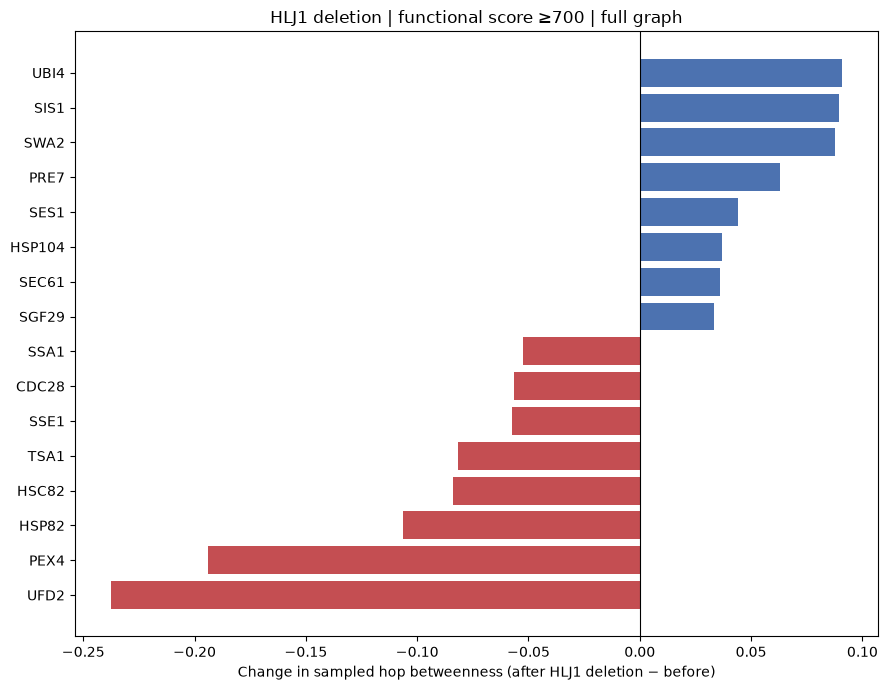

Saved: /Users/kennyyu/math3888-stream-2-group-k/figures/03_hlj1_deletion_betweenness_changes.png


In [9]:
change_column = (
    "bc_hop_sampled_after_minus_before"
)

increases = eligible_primary.nlargest(
    8, change_column
)
decreases = eligible_primary.nsmallest(
    8, change_column
)

plot_data = (
    pd.concat([decreases, increases])
    .drop_duplicates("string_protein_id")
    .sort_values(change_column)
)

fig, ax = plt.subplots(figsize=(9, 7))

labels = (
    plot_data["preferred_name"]
    .where(
        plot_data["preferred_name"].ne(""),
        plot_data["orf"],
    )
)

ax.barh(
    labels,
    plot_data[change_column],
    color=[
        "#4C72B0" if value >= 0 else "#C44E52"
        for value in plot_data[change_column]
    ],
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(
    "Change in sampled hop betweenness "
    "(after HLJ1 deletion − before)"
)
ax.set_title(
    "HLJ1 deletion | functional score ≥700 | full graph"
)

fig.tight_layout()

figure_path = (
    FIGURES / "03_hlj1_deletion_betweenness_changes.png"
)
fig.savefig(figure_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## 7. Export a reproducible audit record

The output retains both sign conventions and the actual before/after values. Keep those columns when sharing results; a ranking alone cannot resolve a sign or denominator ambiguity.

The `>750, largest component` scenario is a comparison with the filter visible in Alex's older notebook. It still may not reproduce his newer result: we need his exact input edge file, centrality function, weighting, and code to verify that.

For the group report, the frozen ≥700 full-network result remains primary. Report scenario disagreement and the degenerate five-seed efficiency endpoint as findings, not errors to hide.

In [10]:
assert results.groupby("scenario").size().eq(
    scenario_summary.set_index(
        "scenario"
    )["nodes_after"]
).all()

for prefix in [
    "pagerank_raw",
    "pagerank_survivors",
    "bc_hop_sampled",
    "bc_conf_sampled",
]:
    assert np.allclose(
        results[f"{prefix}_after_minus_before"],
        -results[f"{prefix}_before_minus_after"],
    )

result_path = (
    OUTPUT / "hlj1_deletion_metric_comparison.csv.gz"
)
summary_path = (
    OUTPUT / "scenario_construction_summary.csv"
)
efficiency_path = (
    OUTPUT / "seed_efficiency_diagnostic.csv"
)
control_path = (
    OUTPUT / "physical_negative_control.csv"
)
record_path = OUTPUT / "run_record.json"

results.to_csv(
    result_path,
    index=False,
    compression="gzip",
)
scenario_summary.to_csv(summary_path, index=False)
efficiency_diagnostic.to_csv(
    efficiency_path, index=False
)
physical_control.to_csv(control_path, index=False)

record = {
    "notebook": "03_hlj1_deletion_method_audit",
    "design_sha256": sha256(design_path),
    "functional_processed_sha256": sha256(
        functional_path
    ),
    "physical_processed_sha256": sha256(
        physical_path
    ),
    "difference_convention": "after_minus_before",
    "pagerank_alpha": 0.85,
    "betweenness_method": (
        "betweenness_centrality_subset; "
        "fixed sources; fixed surviving targets; "
        "unnormalized"
    ),
    "sampled_source_count": SOURCE_SAMPLE_SIZE,
    "sampled_source_seed": SOURCE_RANDOM_SEED,
    "sampled_source_ids": sampled_sources,
    "relative_change_floor": {
        "pagerank": 1e-6,
        "betweenness": 1.0,
    },
    "networkx_version": nx.__version__,
    "pandas_version": pd.__version__,
}

record_path.write_text(
    json.dumps(record, indent=2),
    encoding="utf-8",
)

print("Saved:")
for path in [
    result_path,
    summary_path,
    efficiency_path,
    control_path,
    record_path,
    figure_path,
]:
    print(path)

Saved:
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_03/hlj1_deletion_metric_comparison.csv.gz
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_03/scenario_construction_summary.csv
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_03/seed_efficiency_diagnostic.csv
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_03/physical_negative_control.csv
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_03/run_record.json
/Users/kennyyu/math3888-stream-2-group-k/figures/03_hlj1_deletion_betweenness_changes.png


## 8. Check stability across sampled sources

The previous figure used one fixed sample of 32 source proteins. Its bars may depend on which sources were drawn.

Keep the primary graph, surviving targets, path definition, and difference sign unchanged. Repeat the calculation with 10 predetermined random seeds and 64 sources per repeat. For each protein, retain its score **before**, score **after**, and their difference.

Because raw subset-betweenness grows with the number of sampled sources, report

$$\overline{B}^{(r)}_v=\frac{B^{(r)}_v}{|Q_r|},\qquad\Delta\overline{B}^{(r)}_v=\frac{B^{(r)}_v(G-h)-B^{(r)}_v(G)}{|Q_r|},$$

where $Q_r$ is the source sample in repeat $r$. We will count how often each difference is positive, negative, or effectively zero. These counts describe **computational sampling stability**, not biological uncertainty or a statistical $p$-value.

In [11]:
STABILITY_REPEATS = 10
SOURCES_PER_REPEAT = 64
STABILITY_RANDOM_SEEDS = list(
    range(10001, 10001 + STABILITY_REPEATS)
)
SIGN_TOLERANCE_PER_SOURCE = 1e-10

source_pool = sorted(common_nodes)
surviving_targets = sorted(set(G_primary) - {h})

assert len(source_pool) >= SOURCES_PER_REPEAT
assert set(source_pool) <= set(surviving_targets)
assert set(G_primary_after) == set(surviving_targets)

protein_info = primary_results.loc[
    :,
    [
        "string_protein_id",
        "orf",
        "preferred_name",
        "candidate_eligible",
    ],
].copy()

sample_frames = []
sampled_sources_by_repeat = {}

for repeat_number, random_seed in enumerate(
    STABILITY_RANDOM_SEEDS, start=1
):
    sources = random.Random(random_seed).sample(
        source_pool,
        SOURCES_PER_REPEAT,
    )

    sampled_sources_by_repeat[str(repeat_number)] = {
        "random_seed": random_seed,
        "source_ids": sources,
    }

    before = nx.betweenness_centrality_subset(
        G_primary,
        sources=sources,
        targets=surviving_targets,
        normalized=False,
        weight=None,
    )

    after = nx.betweenness_centrality_subset(
        G_primary_after,
        sources=sources,
        targets=surviving_targets,
        normalized=False,
        weight=None,
    )

    repeat_table = protein_info.copy()
    ids = repeat_table["string_protein_id"]

    repeat_table.insert(0, "repeat", repeat_number)
    repeat_table.insert(1, "random_seed", random_seed)
    repeat_table["sampled_sources"] = len(sources)

    repeat_table["bc_before"] = ids.map(before)
    repeat_table["bc_after"] = ids.map(after)
    repeat_table["bc_after_minus_before"] = (
        repeat_table["bc_after"]
        - repeat_table["bc_before"]
    )

    repeat_table["before_per_source"] = repeat_table["bc_before"] / len(sources)
    repeat_table["delta_per_source"] = repeat_table["bc_after_minus_before"] / len(sources)

    # Match Notebook 03's rule: do not report a percentage
    # when the unscaled baseline is below 1.
    safe_baseline = repeat_table["bc_before"].where(repeat_table["bc_before"] >= 1.0)
    repeat_table["relative_change"] = repeat_table["bc_after_minus_before"] / safe_baseline

    sample_frames.append(repeat_table)
    print(f"Completed repeat {repeat_number}/{STABILITY_REPEATS}")

stability_samples = pd.concat(sample_frames, ignore_index=True)

assert stability_samples.groupby("repeat").size().eq(len(surviving_targets)).all()

display(stability_samples.head()[[
    "repeat",
    "orf",
    "preferred_name",
    "bc_before",
    "bc_after",
    "delta_per_source",
]])

Completed repeat 1/10
Completed repeat 2/10
Completed repeat 3/10
Completed repeat 4/10
Completed repeat 5/10
Completed repeat 6/10
Completed repeat 7/10
Completed repeat 8/10
Completed repeat 9/10
Completed repeat 10/10


,repeat,orf,preferred_name,bc_before,bc_after,delta_per_source
0,1,,Q0010,0.000000,0.000000,0.0
1,1,,Q0017,0.000000,0.000000,0.0
2,1,,Q0032,0.000000,0.000000,0.0
3,1,,COX1,67.862171,67.862171,0.0
4,1,,AI1,0.215149,0.215149,0.0


## 9. Summarise signs, magnitudes, and baseline scores

For each protein, report the median and range of the 10 per-source changes, alongside its median **baseline** betweenness per source. A positive sign in all 10 repeats is more stable than one produced by a single sample, but a stable sign can still accompany a very small change.

The relative-change column remains secondary: dividing by a small baseline can make an unimportant absolute change look large. Keep KAR2 as a prespecified readout and SSM4 as a Notebook 02 comparison protein; neither is a newly discovered candidate merely because it appears in this table.

In [12]:
eligible_mask = stability_samples["candidate_eligible"]

stability_samples["candidate_positive_rank"] = np.nan
stability_samples.loc[
    eligible_mask, "candidate_positive_rank"
] = (stability_samples.loc[eligible_mask]
    .groupby("repeat")["delta_per_source"]
    .rank(ascending=False, method="min"))

stability_summary = (
    stability_samples.groupby("string_protein_id", as_index=False).agg(
        orf=("orf", "first"),
        preferred_name=("preferred_name", "first"),
        candidate_eligible=(
            "candidate_eligible", "first"
        ),
        median_baseline_per_source=(
            "before_per_source", "median"
        ),
        median_delta_per_source=(
            "delta_per_source", "median"
        ),
        q25_delta_per_source=(
            "delta_per_source",
            lambda values: values.quantile(0.25),
        ),
        q75_delta_per_source=(
            "delta_per_source",
            lambda values: values.quantile(0.75),
        ),
        min_delta_per_source=(
            "delta_per_source", "min"
        ),
        max_delta_per_source=(
            "delta_per_source", "max"
        ),
        positive_repeats=(
            "delta_per_source",
            lambda values: int(
                (
                    values
                    > SIGN_TOLERANCE_PER_SOURCE
                ).sum()
            ),
        ),
        negative_repeats=(
            "delta_per_source",
            lambda values: int(values < -SIGN_TOLERANCE_PER_SOURCE).sum(),
        ),
        median_relative_change=("relative_change", "median"),
        median_candidate_positive_rank=("candidate_positive_rank", "median"),
    )
)

stability_summary["near_zero_repeats"] = (
    STABILITY_REPEATS
    - stability_summary["positive_repeats"]
    - stability_summary["negative_repeats"]
)

STABILITY_FOCUS_ORFS = [
    "YJL162C",  # JJJ2
    "YNL077W",  # APJ1
    "YLR090W",  # XDJ1
    "YHR110W",  # ERP5
    "YIL030C",  # SSM4
    "YJL034W",  # KAR2: prespecified readout
    "YLL039C",  # UBI4: large bar in prior figure
    "YNL007C",  # SIS1
    "YDR320C",  # SWA2
    "YDL190C",  # UFD2
]

focus_stability = stability_summary.loc[
    stability_summary["orf"].isin(
        STABILITY_FOCUS_ORFS
    ),
    [
        "orf",
        "preferred_name",
        "median_baseline_per_source",
        "median_delta_per_source",
        "min_delta_per_source",
        "max_delta_per_source",
        "positive_repeats",
        "negative_repeats",
        "near_zero_repeats",
        "median_relative_change",
        "median_candidate_positive_rank",
    ],
].sort_values(
    "median_delta_per_source",
    ascending=False,
)

display(focus_stability)

print("Most consistently positive eligible proteins:")
display(
    stability_summary.loc[
        stability_summary["candidate_eligible"]
        & stability_summary["positive_repeats"].eq(
            STABILITY_REPEATS
        )
    ]
    .sort_values(
        "median_delta_per_source",
        ascending=False,
    )
    .head(15)[
        [
            "orf",
            "preferred_name",
            "median_baseline_per_source",
            "median_delta_per_source",
            "positive_repeats",
            "median_relative_change",
            "median_candidate_positive_rank",
        ]
    ]
)

,orf,preferred_name,median_baseline_per_source,median_delta_per_source,min_delta_per_source,max_delta_per_source,positive_repeats,negative_repeats,near_zero_repeats,median_relative_change,median_candidate_positive_rank
5062,YNL007C,SIS1,4.425161,0.003686,0.003038,0.009149,10,0,0,0.000829,3.0
4013,YLL039C,UBI4,50.096418,0.003023,0.001609,0.017450,10,0,0,0.000067,4.5
1378,YDR320C,SWA2,3.215113,0.001994,-0.001998,0.014588,9,1,0,0.000860,8.5
4134,YLR090W,XDJ1,0.255141,0.001531,0.001053,0.006686,10,0,0,0.006233,10.0
5135,YNL077W,APJ1,0.142236,0.001276,0.000913,0.001733,10,0,0,0.007812,12.0
3395,YJL162C,JJJ2,0.094590,0.001013,0.000738,0.005499,10,0,0,0.012787,18.0
2857,YHR110W,ERP5,0.001201,0.000000,0.000000,0.000000,0,0,10,NaN,1397.5
3260,YJL034W,KAR2,19.663910,-0.002203,-0.006726,0.087977,2,8,0,-0.000121,NaN
986,YDL190C,UFD2,0.205445,-0.002370,-0.062003,-0.000745,0,10,0,-0.017234,6560.5
3022,YIL030C,SSM4,1.302366,-0.004898,-0.036610,-0.001137,0,10,0,-0.004118,6561.0


Most consistently positive eligible proteins:


,orf,preferred_name,median_baseline_per_source,median_delta_per_source,positive_repeats,median_relative_change,median_candidate_positive_rank
5062,YNL007C,SIS1,4.425161,0.003686,10,0.000829,3.0
4013,YLL039C,UBI4,50.096418,0.003023,10,0.000067,4.5
916,YDL126C,CDC48,17.443545,0.002780,10,0.000194,3.5
4454,YLR378C,SEC61,32.871894,0.002580,10,0.000074,7.0
4930,YMR214W,SCJ1,1.115495,0.002394,10,0.001989,6.0
1962,YFL016C,MDJ1,0.231868,0.001549,10,0.007188,9.5
4134,YLR090W,XDJ1,0.255141,0.001531,10,0.006233,10.0
5135,YNL077W,APJ1,0.142236,0.001276,10,0.007812,12.0
1452,YDR385W,EFT2,11.827239,0.001109,10,0.000072,21.0
5914,YOR232W,MGE1,4.879284,0.001104,10,0.000292,11.0


## 10. Plot variation without hiding the baseline

Each point below is the median change per sampled source; its horizontal line spans the minimum to maximum across the 10 repeats. The label also shows the median baseline score per source.

These ranges are descriptive **sampling ranges**, not confidence intervals. The two panels use different horizontal scales so the smaller positive changes remain legible.

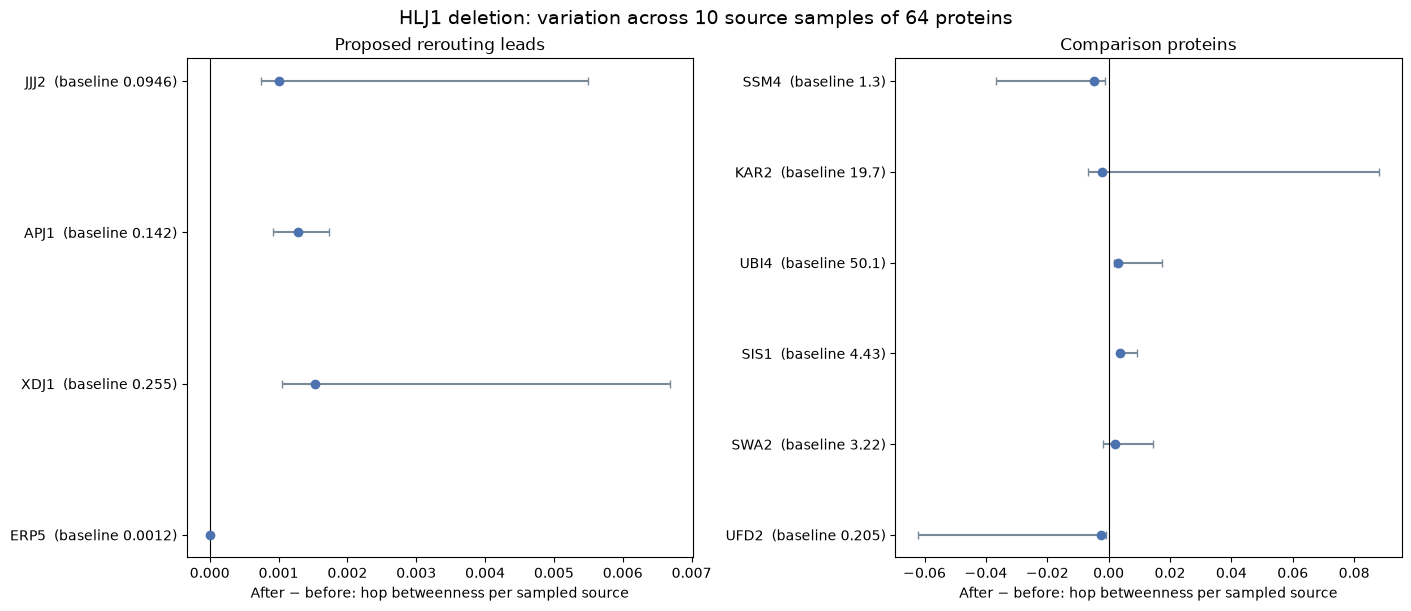

Saved: /Users/kennyyu/math3888-stream-2-group-k/figures/03_hlj1_candidate_sampling_stability.png


In [14]:
plot_panels = {
    "Proposed rerouting leads": [
        "YJL162C",  # JJJ2
        "YNL077W",  # APJ1
        "YLR090W",  # XDJ1
        "YHR110W",  # ERP5
    ],
    "Comparison proteins": [
        "YIL030C",  # SSM4
        "YJL034W",  # KAR2
        "YLL039C",  # UBI4
        "YNL007C",  # SIS1
        "YDR320C",  # SWA2
        "YDL190C",  # UFD2
    ],
}

fig, axes = plt.subplots(
    1, 2, figsize=(14, 6),
    constrained_layout=True,
)

for ax, (panel_title, orfs) in zip(axes, plot_panels.items()):
    panel = (
        stability_summary.loc[stability_summary["orf"].isin(orfs)]
        .set_index("orf", verify_integrity=True)
        .reindex(orfs)
        .dropna(subset=["median_delta_per_source"])
    )

    positions = np.arange(len(panel))
    median = panel["median_delta_per_source"].to_numpy()
    lower = median - panel["min_delta_per_source"].to_numpy()
    upper = panel["max_delta_per_source"].to_numpy() - median

    labels = [(
        f"{row.preferred_name}  "
        f"(baseline {row.median_baseline_per_source:.3g})"
    )
    for row in panel.itertuples()]

    ax.errorbar(
        median,
        positions,
        xerr=np.vstack([lower, upper]),
        fmt="o",
        color="#4C72B0",
        ecolor="#7A8998",
        capsize=3,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(positions)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_title(panel_title)
    ax.set_xlabel(
        "After − before: hop betweenness "
        "per sampled source"
    )

fig.suptitle(
    "HLJ1 deletion: variation across "
    "10 source samples of 64 proteins",
    fontsize=14,
)

stability_figure_path = FIGURES / "03_hlj1_candidate_sampling_stability.png"
fig.savefig(
    stability_figure_path,
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print("Saved:", stability_figure_path)

## 11. Export the stability check

Save all repeat-level values, the one-row-per-protein summary, and the exact source IDs drawn in each repeat. This makes the stability claim independently reproducible.

Interpret a positive sign across repeats as evidence that the **network-path calculation** is stable under this sampling scheme. It is not evidence that HLJ1 deletion activates the protein. Candidate selection still requires pathway relevance, evidence-type review, and input from BCMB.

In [15]:
sample_path = OUTPUT / "hop_betweenness_sampling_repeats.csv.gz"
stability_summary_path = OUTPUT / "hop_betweenness_stability_summary.csv"
stability_record_path = OUTPUT / "stability_run_record.json"

stability_samples.to_csv(sample_path, index=False, compression="gzip")
stability_summary.to_csv(stability_summary_path, index=False)

stability_record = {
    "analysis": (
        "primary functional >=700; "
        "HLJ1 deletion; fixed surviving targets"
    ),
    "design_sha256": sha256(design_path),
    "functional_processed_sha256": sha256(functional_path),
    "original_notebook_03_record_sha256": sha256(record_path),
    "method": (
        "betweenness_centrality_subset; "
        "unnormalized; minimum-hop paths; "
        "after_minus_before"
    ),
    "repeat_count": STABILITY_REPEATS,
    "sources_per_repeat": SOURCES_PER_REPEAT,
    "source_pool_rule": (
        "proteins present in all five Notebook 03 "
        "functional scenarios, excluding HLJ1"
    ),
    "source_pool_size": len(source_pool),
    "target_count": len(surviving_targets),
    "sign_tolerance_per_source": SIGN_TOLERANCE_PER_SOURCE,
    "source_ids_by_repeat": sampled_sources_by_repeat,
    "sample_table_sha256": sha256(sample_path),
    "summary_table_sha256": sha256(stability_summary_path),
}

stability_record_path.write_text(
    json.dumps(
        stability_record,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

assert stability_summary[
    [
        "positive_repeats",
        "negative_repeats",
        "near_zero_repeats",
    ]
].sum(axis=1).eq(STABILITY_REPEATS).all()

print("Saved:")
for path in [
    sample_path,
    stability_summary_path,
    stability_record_path,
    stability_figure_path,
]:
    print(path)

Saved:
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_03/hop_betweenness_sampling_repeats.csv.gz
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_03/hop_betweenness_stability_summary.csv
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_03/stability_run_record.json
/Users/kennyyu/math3888-stream-2-group-k/figures/03_hlj1_candidate_sampling_stability.png
